# Olist Review Classification — Combined Models
## Dự đoán đánh giá Tốt/Xấu của khách hàng Olist

**Bài toán:** Phân loại nhị phân review của khách hàng sau khi đơn hàng được giao:
- `0` = **Negative** (review 1–3 sao)
- `1` = **Positive** (review 4–5 sao)

**Mục tiêu nghiệp vụ:** cảnh báo sớm các đơn hàng có nguy cơ nhận **review xấu (class 0)**. Vì dữ liệu mất cân bằng (~21% class 0), ngoài *accuracy* nhóm tập trung vào **precision / recall / F1 của class 0**.

Notebook này gộp **4 mô hình** trên cùng một pipeline tiền xử lý và cùng bộ **14 features**:

| # | Model | Thành viên |
|---|-------|-----------|
| 1 | Decision Tree | Dang Cao Cuong |
| 2 | K-Nearest Neighbors (KNN) | Le Minh Tri |
| 3 | Logistic Regression | Nguyen Phuc Hau |
| 4 | Random Forest | Tran Quoc An |

Mỗi mô hình gồm phiên bản *baseline* và phiên bản *cải thiện* (cân bằng dữ liệu / điều chỉnh ngưỡng) nhằm tăng khả năng bắt review xấu. Cuối notebook là phần **so sánh tổng hợp** giữa các mô hình.

### Mức độ đóng góp của từng thành viên:
- **Trần Quốc An** (Train model, làm slide, thuyết trình): 22%
- **Lê Minh Trí** (Train model, làm slide, thuyết trình): 22%
- **Nguyễn Phúc Hậu** (Train model, làm slide, thuyết trình): 22%
- **Đặng Cao Cường** (Train model, làm slide, thuyết trình): 22%
- **Lê Triết Huân** (Xử lý data): 12%


## 0. Import thư viện (Imports)

In [1]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)

# imbalanced-learn: SMOTE (xu ly mat can bang). Neu chua cai: pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (6, 5)

## 1. Tiền xử lý dữ liệu (Data Preprocessing)

Gộp các bảng Olist (reviews, orders, customers, items, payments, products), tạo đặc trưng vận hành / thanh toán / sản phẩm, tạo nhãn `review_label`, làm sạch, encode và chia train/test (80/20, stratify). Kết quả là **14 features** dùng chung cho cả 4 mô hình.

In [2]:
# Tu do thu muc chua du lieu raw Olist (chay duoc tu Improved/, project root, hoac "14 features/").
_raw_candidates = ["data", "14 features", ".", os.path.join("..", "14 features"), ".."]
RAW_DIR = next((d for d in _raw_candidates
                if os.path.exists(os.path.join(d, "olist_orders_dataset.csv"))), ".")
print("Loading raw Olist data from:", os.path.abspath(RAW_DIR))

customers = pd.read_csv(os.path.join(RAW_DIR, "olist_customers_dataset.csv"))
orders    = pd.read_csv(os.path.join(RAW_DIR, "olist_orders_dataset.csv"))
reviews   = pd.read_csv(os.path.join(RAW_DIR, "olist_order_reviews_dataset.csv"))
items     = pd.read_csv(os.path.join(RAW_DIR, "olist_order_items_dataset.csv"))
payments  = pd.read_csv(os.path.join(RAW_DIR, "olist_order_payments_dataset.csv"))
products  = pd.read_csv(os.path.join(RAW_DIR, "olist_products_dataset.csv"))

# Base: reviews + orders + customers
df = (reviews.merge(orders, on="order_id", how="inner")
             .merge(customers, on="customer_id", how="left"))

# Item features (gop theo don hang)
item_features = items.groupby("order_id").agg({"price": "sum", "freight_value": "sum"}).reset_index()
item_features.rename(columns={"price": "total_price"}, inplace=True)

# Payment features + dominant payment type
payment_features = payments.groupby("order_id").agg(
    {"payment_value": "sum", "payment_installments": "mean"}).reset_index()
payment_type = (payments.groupby("order_id")["payment_type"]
                .agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else "unknown").reset_index())
payment_features = payment_features.merge(payment_type, on="order_id", how="left")

# Product features (+ product_volume)
product_features = items.merge(products, on="product_id", how="left")
product_features["product_volume"] = (product_features["product_length_cm"]
                                       * product_features["product_height_cm"]
                                       * product_features["product_width_cm"])
product_features = product_features.groupby("order_id").agg({
    "product_weight_g": "mean", "product_photos_qty": "mean",
    "product_description_lenght": "mean", "product_volume": "mean"}).reset_index()

df = (df.merge(item_features, on="order_id", how="left")
        .merge(payment_features, on="order_id", how="left")
        .merge(product_features, on="order_id", how="left"))
df = df.drop_duplicates(subset="order_id")
print("Merged dataframe shape:", df.shape)

Loading raw Olist data from: c:\Users\qanpr\OneDrive\Documents\CSE\CSW 439\Project\data
Merged dataframe shape: (98673, 27)


In [3]:
# Feature engineering: thoi gian giao hang, tre han, ti le phi ship
date_columns = ["order_purchase_timestamp", "order_delivered_customer_date",
                "order_estimated_delivery_date"]
for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df["delivery_days"] = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.days
df["delay_days"]    = (df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]).dt.days
df["delay_days"]    = df["delay_days"].fillna(0)
df["is_late"]       = (df["delay_days"] > 0).astype(int)
df["freight_ratio"] = np.where(df["total_price"] > 0, df["freight_value"] / df["total_price"], 0)

# Target: review_score 1-3 -> 0 (Negative), 4-5 -> 1 (Positive)
df["review_label"] = np.where(df["review_score"] <= 3, 0, 1)
print("Target distribution:")
print(df["review_label"].value_counts())

Target distribution:
review_label
1    76063
0    22610
Name: count, dtype: int64


In [4]:
# Chon 14 features + label, drop NaN, encode bien phan loai
selected_features = [
    "delivery_days", "delay_days", "is_late", "payment_value", "payment_installments",
    "payment_type", "total_price", "freight_value", "freight_ratio", "customer_state",
    "product_weight_g", "product_photos_qty", "product_description_lenght",
    "product_volume", "review_label"]

final_df = df[selected_features].copy().dropna()
final_df["customer_state"] = LabelEncoder().fit_transform(final_df["customer_state"])
final_df["payment_type"]   = LabelEncoder().fit_transform(final_df["payment_type"])

print("Final shape (14 features + label):", final_df.shape)
final_df.head()

Final shape (14 features + label): (94504, 15)


,delivery_days,delay_days,is_late,payment_value,payment_installments,payment_type,total_price,freight_value,freight_ratio,customer_state,product_weight_g,product_photos_qty,product_description_lenght,product_volume,review_label
0,6.0,-16.0,0,397.26,8.0,1,370.00,27.26,0.073676,25,1300.0,1.0,858.0,31500.0,1
1,9.0,-5.0,0,88.09,1.0,1,79.79,8.30,0.104023,25,245.0,1.0,493.0,3724.0,1
2,13.0,-21.0,0,194.12,1.0,1,149.00,45.12,0.302819,4,6550.0,1.0,1893.0,8000.0,1
3,10.0,-20.0,0,222.84,1.0,1,179.99,42.85,0.238069,23,7650.0,2.0,2188.0,8000.0,1
4,18.0,-9.0,0,1333.25,10.0,1,1199.00,134.25,0.111968,23,9850.0,5.0,562.0,183750.0,1


In [5]:
# Train/test split (80/20, stratify) + ban scaled cho cac model tuyen tinh/khoang cach
X = final_df.drop("review_label", axis=1)
y = final_df["review_label"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Features (14):", list(X_train.columns))

X_train: (75603, 14) | X_test: (18901, 14)
Features (14): ['delivery_days', 'delay_days', 'is_late', 'payment_value', 'payment_installments', 'payment_type', 'total_price', 'freight_value', 'freight_ratio', 'customer_state', 'product_weight_g', 'product_photos_qty', 'product_description_lenght', 'product_volume']


### Hàm đánh giá dùng chung (Unified evaluation helper)

`summarize_model(...)` in classification report, vẽ confusion matrix và lưu các chỉ số (accuracy, precision / recall / F1 của **class 0**, F1 weighted) vào `all_results` để so sánh ở cuối notebook.

In [6]:
all_results = []

def summarize_model(name, y_true, y_pred, cmap="Blues", plot=True):
    """Danh gia thong nhat cho moi model: tap trung vao class 0 (review xau)."""
    metrics = {
        "model": name,
        "accuracy":      accuracy_score(y_true, y_pred),
        "precision_neg0": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "recall_neg0":    recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "f1_neg0":        f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        "f1_weighted":    f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }
    print("=" * 60); print(name); print("=" * 60)
    print(classification_report(y_true, y_pred,
                                target_names=["Negative (0)", "Positive (1)"], zero_division=0))
    if plot:
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        ConfusionMatrixDisplay(cm, display_labels=["Negative (0)", "Positive (1)"]).plot(
            cmap=cmap, values_format="d")
        plt.title(name); plt.grid(False); plt.show()
    all_results.append(metrics)
    return metrics

## 2. Decision Tree

Mô hình cây quyết định chia dữ liệu theo các điều kiện `if/else`. **Ưu điểm:** dễ giải thích, không cần chuẩn hóa, xử lý được quan hệ phi tuyến. **Nhược điểm:** dễ overfit nếu cây quá sâu.

**Baseline:** `max_depth=6`, `min_samples_leaf=10`, `class_weight='balanced'`.

Decision Tree (baseline)
              precision    recall  f1-score   support

Negative (0)       0.39      0.47      0.43      3976
Positive (1)       0.85      0.81      0.83     14925

    accuracy                           0.74     18901
   macro avg       0.62      0.64      0.63     18901
weighted avg       0.75      0.74      0.74     18901



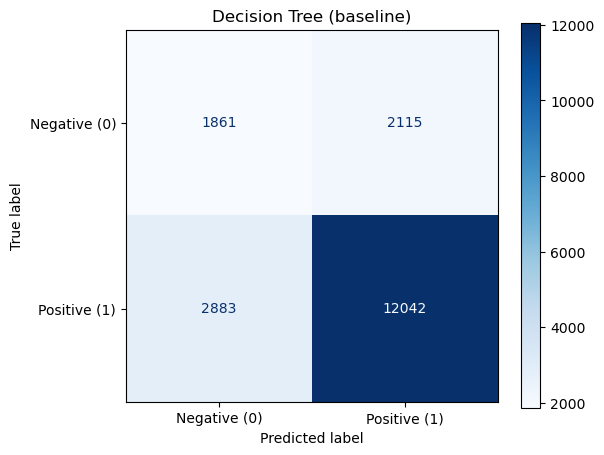

{'model': 'Decision Tree (baseline)',
 'accuracy': 0.7355695465848368,
 'precision_neg0': 0.39228499156829677,
 'recall_neg0': 0.46805835010060365,
 'f1_neg0': 0.4268348623853211,
 'f1_weighted': 0.7437226391322966}

In [7]:
dt_model = DecisionTreeClassifier(criterion="gini", max_depth=6, min_samples_leaf=10,
                                  class_weight="balanced", random_state=RANDOM_STATE)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
summarize_model("Decision Tree (baseline)", y_test, y_pred_dt, cmap="Blues")

### Cải thiện: grid search + threshold (mục tiêu Recall class 0 ≥ 0.55)

Chia train → fit/val, dò `max_depth`, `min_samples_leaf`, `class_weight` rồi dò ngưỡng quyết định; giữ phương án đạt recall xấu mục tiêu với accuracy cao nhất.

Selected threshold (predict Positive if P1 >=): 0.5
Decision Tree (optimized)
              precision    recall  f1-score   support

Negative (0)       0.30      0.64      0.41      3976
Positive (1)       0.86      0.60      0.71     14925

    accuracy                           0.61     18901
   macro avg       0.58      0.62      0.56     18901
weighted avg       0.74      0.61      0.64     18901



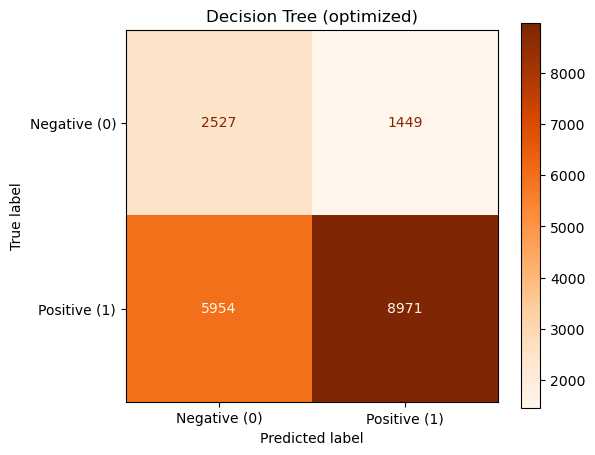

{'model': 'Decision Tree (optimized)',
 'accuracy': 0.608327601714195,
 'precision_neg0': 0.29796014620917344,
 'recall_neg0': 0.6355633802816901,
 'f1_neg0': 0.40571566187685637,
 'f1_weighted': 0.6443412844511139}

In [8]:
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE)

target_recall_bad = 0.55
best_model, best_val_acc = None, -1
for max_depth in [5, 6, 7, 8]:
    for min_leaf in [10, 20, 40]:
        for bad_weight in [2.5, 3.0, 3.5, 4.0, 5.0]:
            m = DecisionTreeClassifier(criterion="gini", max_depth=max_depth,
                                       min_samples_leaf=min_leaf,
                                       class_weight={0: bad_weight, 1: 1.0},
                                       random_state=RANDOM_STATE)
            m.fit(X_fit, y_fit)
            vp = m.predict(X_val)
            if (recall_score(y_val, vp, pos_label=0, zero_division=0) >= target_recall_bad
                    and accuracy_score(y_val, vp) > best_val_acc):
                best_model, best_val_acc = m, accuracy_score(y_val, vp)

best_threshold, best_threshold_acc = 0.5, -1
for t in [0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]:
    vp = (best_model.predict_proba(X_val)[:, 1] >= t).astype(int)
    if (recall_score(y_val, vp, pos_label=0, zero_division=0) >= target_recall_bad
            and accuracy_score(y_val, vp) > best_threshold_acc):
        best_threshold, best_threshold_acc = t, accuracy_score(y_val, vp)

print("Selected threshold (predict Positive if P1 >=):", best_threshold)
y_pred_dt_opt = (best_model.predict_proba(X_test)[:, 1] >= best_threshold).astype(int)
summarize_model("Decision Tree (optimized)", y_test, y_pred_dt_opt, cmap="Oranges")

## 3. K-Nearest Neighbors (KNN)

KNN phân loại dựa trên `K` láng giềng gần nhất theo **khoảng cách**, nên **cần chuẩn hóa dữ liệu** (`StandardScaler` đặt trong `Pipeline`). `K` được chọn theo **F1 của class 0** trên một sample của tập train cho nhanh.

In [9]:
# Sample tu train de thu nhanh nhieu gia tri K
X_tune, _, y_tune, _ = train_test_split(
    X_train, y_train, train_size=20000, random_state=RANDOM_STATE, stratify=y_train)
X_tt, X_tv, y_tt, y_tv = train_test_split(
    X_tune, y_tune, test_size=0.25, random_state=RANDOM_STATE, stratify=y_tune)

k_rows = []
for k in [3, 5, 7, 11, 15]:
    cand = Pipeline([("scaler", StandardScaler()),
                     ("knn", KNeighborsClassifier(n_neighbors=k, weights="distance", n_jobs=2))])
    cand.fit(X_tt, y_tt)
    vp = cand.predict(X_tv)
    k_rows.append({"k": k,
                   "f1_class_0": f1_score(y_tv, vp, pos_label=0, zero_division=0),
                   "recall_class_0": recall_score(y_tv, vp, pos_label=0, zero_division=0),
                   "accuracy": accuracy_score(y_tv, vp)})
k_df = pd.DataFrame(k_rows)
print(k_df.round(4))
best_k = int(k_df.sort_values("f1_class_0", ascending=False).iloc[0]["k"])
print("Best K (theo F1 class 0):", best_k)

    k  f1_class_0  recall_class_0  accuracy
0   3      0.3652          0.2956    0.7838
1   5      0.3713          0.2757    0.8036
2   7      0.3678          0.2605    0.8116
3  11      0.3686          0.2481    0.8212
4  15      0.3639          0.2414    0.8224
Best K (theo F1 class 0): 5


KNN baseline (k=5)
              precision    recall  f1-score   support

Negative (0)       0.52      0.25      0.34      3976
Positive (1)       0.83      0.94      0.88     14925

    accuracy                           0.79     18901
   macro avg       0.68      0.60      0.61     18901
weighted avg       0.76      0.79      0.77     18901



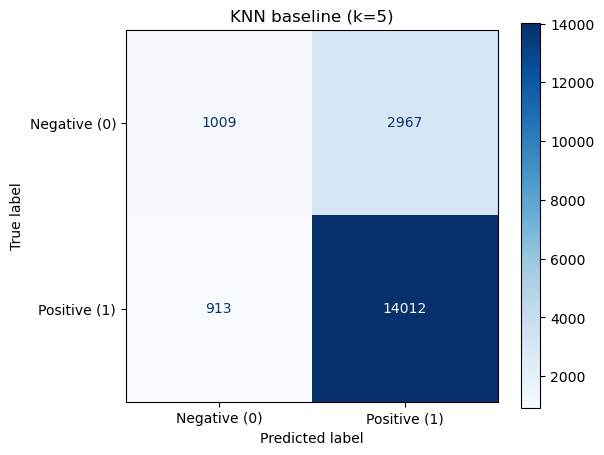

{'model': 'KNN baseline (k=5)',
 'accuracy': 0.7947198560922702,
 'precision_neg0': 0.5249739854318418,
 'recall_neg0': 0.25377263581488935,
 'f1_neg0': 0.34214988131570023,
 'f1_weighted': 0.7655831105998218}

In [10]:
# Train KNN baseline tren toan bo train: StandardScaler -> KNN (weights="distance")
knn_model = Pipeline([("scaler", StandardScaler()),
                      ("knn", KNeighborsClassifier(n_neighbors=best_k, weights="distance", n_jobs=2))])
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
summarize_model(f"KNN baseline (k={best_k})", y_test, y_pred_knn, cmap="Blues")

### Cải thiện: SMOTE + hạ ngưỡng quyết định

**SMOTE** (đặt trong `imblearn.Pipeline` để chỉ oversample trên train, tránh rò rỉ dữ liệu) sinh thêm mẫu class 0; chọn `K` theo **recall**; sau đó **hạ ngưỡng** để đạt recall class 0 ≥ 0.60.

    k  recall_class_0  f1_class_0
0   5          0.5418      0.3751
1  11          0.5760      0.3888
2  15          0.5770      0.3904
3  21          0.5722      0.3910
4  25          0.5741      0.3901
Best K (theo recall class 0): 15
Chosen threshold P(0) >=: 0.45
KNN (SMOTE k=15 + threshold 0.45)
              precision    recall  f1-score   support

Negative (0)       0.28      0.60      0.38      3976
Positive (1)       0.85      0.58      0.69     14925

    accuracy                           0.58     18901
   macro avg       0.56      0.59      0.53     18901
weighted avg       0.73      0.58      0.62     18901



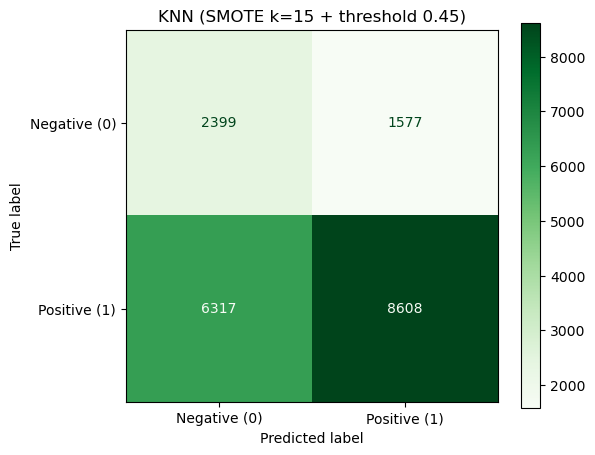

{'model': 'KNN (SMOTE k=15 + threshold 0.45)',
 'accuracy': 0.582350140204222,
 'precision_neg0': 0.2752409362092703,
 'recall_neg0': 0.6033702213279678,
 'f1_neg0': 0.3780334068704696,
 'f1_weighted': 0.6209188903436879}

In [11]:
k_rec = []
for k in [5, 11, 15, 21, 25]:
    cand = ImbPipeline([("scaler", StandardScaler()),
                        ("smote", SMOTE(random_state=RANDOM_STATE)),
                        ("knn", KNeighborsClassifier(n_neighbors=k, weights="distance", n_jobs=2))])
    cand.fit(X_tt, y_tt)
    vp = cand.predict(X_tv)
    k_rec.append({"k": k,
                  "recall_class_0": recall_score(y_tv, vp, pos_label=0, zero_division=0),
                  "f1_class_0": f1_score(y_tv, vp, pos_label=0, zero_division=0)})
k_rec_df = pd.DataFrame(k_rec)
best_k_recall = int(k_rec_df.sort_values(["recall_class_0", "f1_class_0"], ascending=False).iloc[0]["k"])
print(k_rec_df.round(4))
print("Best K (theo recall class 0):", best_k_recall)

knn_smote = ImbPipeline([("scaler", StandardScaler()),
                         ("smote", SMOTE(random_state=RANDOM_STATE)),
                         ("knn", KNeighborsClassifier(n_neighbors=best_k_recall,
                                                      weights="distance", n_jobs=2))])
knn_smote.fit(X_train, y_train)

proba_neg = knn_smote.predict_proba(X_test)[:, 0]  # P(class 0)
TARGET_RECALL = 0.60
chosen_threshold = 0.5
for t in np.round(np.arange(0.20, 0.501, 0.01), 3):
    if recall_score(y_test, np.where(proba_neg >= t, 0, 1), pos_label=0, zero_division=0) >= TARGET_RECALL:
        chosen_threshold = float(t)
print("Chosen threshold P(0) >=:", chosen_threshold)

y_pred_knn_final = np.where(proba_neg >= chosen_threshold, 0, 1)
summarize_model(f"KNN (SMOTE k={best_k_recall} + threshold {chosen_threshold})",
                y_test, y_pred_knn_final, cmap="Greens")

## 4. Logistic Regression

Mô hình tuyến tính ước lượng xác suất thuộc class Positive. Dùng dữ liệu đã **chuẩn hóa** (`X_train_scaled`). Baseline dùng `class_weight='balanced'`.

Logistic Regression (baseline)
              precision    recall  f1-score   support

Negative (0)       0.40      0.42      0.41      3976
Positive (1)       0.84      0.83      0.84     14925

    accuracy                           0.74     18901
   macro avg       0.62      0.63      0.62     18901
weighted avg       0.75      0.74      0.75     18901



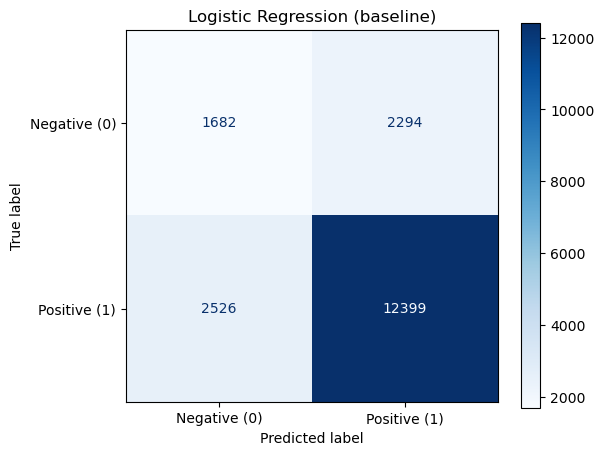

{'model': 'Logistic Regression (baseline)',
 'accuracy': 0.7449870377228718,
 'precision_neg0': 0.3997148288973384,
 'recall_neg0': 0.42303822937625757,
 'f1_neg0': 0.41104594330400784,
 'f1_weighted': 0.7476028231879666}

In [12]:
lr_model = LogisticRegression(random_state=RANDOM_STATE, class_weight="balanced", max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
summarize_model("Logistic Regression (baseline)", y_test, y_pred_lr, cmap="Blues")

### Cải thiện: SMOTE + threshold tuning

Cân bằng tập train bằng SMOTE rồi nâng ngưỡng quyết định lên 0.55 để tăng recall của class 0.

Logistic Regression (SMOTE + threshold 0.55)
              precision    recall  f1-score   support

Negative (0)       0.32      0.57      0.41      3976
Positive (1)       0.85      0.67      0.75     14925

    accuracy                           0.65     18901
   macro avg       0.58      0.62      0.58     18901
weighted avg       0.74      0.65      0.68     18901



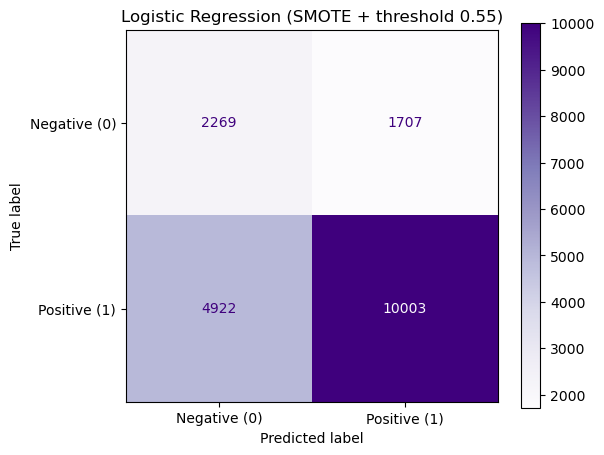

{'model': 'Logistic Regression (SMOTE + threshold 0.55)',
 'accuracy': 0.649277815988572,
 'precision_neg0': 0.3155333055207899,
 'recall_neg0': 0.5706740442655935,
 'f1_neg0': 0.40637592907674397,
 'f1_weighted': 0.6785974918444581}

In [13]:
X_tr_smote, y_tr_smote = SMOTE(random_state=RANDOM_STATE).fit_resample(X_train_scaled, y_train)
lr_smote = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr_smote.fit(X_tr_smote, y_tr_smote)

SMOTE_THRESHOLD = 0.55
y_prob_lr = lr_smote.predict_proba(X_test_scaled)[:, 1]
y_pred_lr_smote = np.where(y_prob_lr > SMOTE_THRESHOLD, 1, 0)
summarize_model(f"Logistic Regression (SMOTE + threshold {SMOTE_THRESHOLD})",
                y_test, y_pred_lr_smote, cmap="Purples")

## 5. Random Forest

Ensemble gồm nhiều cây quyết định, dự đoán theo biểu quyết đa số — mạnh và ít overfit hơn cây đơn. Baseline dùng `n_estimators=100`, `class_weight='balanced'`.

Random Forest (baseline)
              precision    recall  f1-score   support

Negative (0)       0.73      0.22      0.34      3976
Positive (1)       0.83      0.98      0.90     14925

    accuracy                           0.82     18901
   macro avg       0.78      0.60      0.62     18901
weighted avg       0.81      0.82      0.78     18901



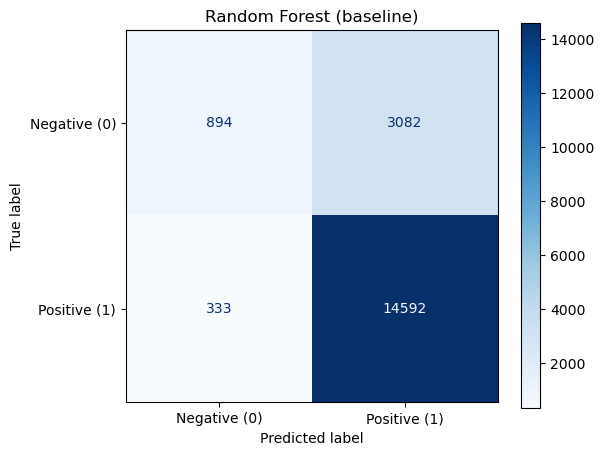

{'model': 'Random Forest (baseline)',
 'accuracy': 0.8193217290090471,
 'precision_neg0': 0.7286063569682152,
 'recall_neg0': 0.22484909456740443,
 'f1_neg0': 0.3436478954449356,
 'f1_weighted': 0.7792092295928766}

In [14]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE,
                                  class_weight="balanced", n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
summarize_model("Random Forest (baseline)", y_test, y_pred_rf, cmap="Blues")

### Cải thiện: cân bằng bằng undersampling + threshold

Random undersampling class 1 về tỉ lệ 50/50 rồi train lại, kết hợp nâng ngưỡng lên 0.60 để bắt nhiều review xấu hơn.

Balanced training set: 31812 (class0=15906, class1=15906)
Random Forest (undersampling + threshold 0.6)
              precision    recall  f1-score   support

Negative (0)       0.27      0.73      0.39      3976
Positive (1)       0.87      0.46      0.60     14925

    accuracy                           0.52     18901
   macro avg       0.57      0.60      0.50     18901
weighted avg       0.74      0.52      0.56     18901



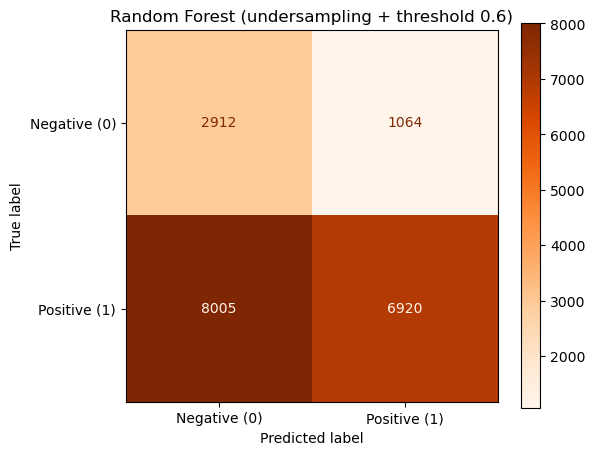

{'model': 'Random Forest (undersampling + threshold 0.6)',
 'accuracy': 0.5201841172424739,
 'precision_neg0': 0.26673994687185126,
 'recall_neg0': 0.7323943661971831,
 'f1_neg0': 0.39105620089975157,
 'f1_weighted': 0.5593074690838828}

In [15]:
df_train = pd.concat([X_train, y_train], axis=1)
c0 = df_train[df_train["review_label"] == 0]
c1 = df_train[df_train["review_label"] == 1].sample(n=len(c0), random_state=RANDOM_STATE)
balanced = pd.concat([c0, c1])
X_bal, y_bal = balanced.drop("review_label", axis=1), balanced["review_label"]
print(f"Balanced training set: {X_bal.shape[0]} (class0={len(c0)}, class1={len(c1)})")

rf_bal = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_bal.fit(X_bal, y_bal)

THRESH_RF = 0.60
y_prob_rf = rf_bal.predict_proba(X_test)[:, 1]
y_pred_rf_bal = (y_prob_rf >= THRESH_RF).astype(int)
summarize_model(f"Random Forest (undersampling + threshold {THRESH_RF})",
                y_test, y_pred_rf_bal, cmap="Oranges")

## 6. So sánh tổng hợp các mô hình (Model Comparison)

Bảng dưới tổng hợp chỉ số của tất cả phiên bản. Trọng tâm là **Recall / F1 của class 0** (review xấu) — chỉ số quan trọng nhất với mục tiêu cảnh báo sớm.

In [16]:
results_df = pd.DataFrame(all_results)[
    ["model", "accuracy", "precision_neg0", "recall_neg0", "f1_neg0", "f1_weighted"]]
results_df.round(4)

,model,accuracy,precision_neg0,recall_neg0,f1_neg0,f1_weighted
0,Decision Tree (baseline),0.7356,0.3923,0.4681,0.4268,0.7437
1,Decision Tree (optimized),0.6083,0.2980,0.6356,0.4057,0.6443
2,KNN baseline (k=5),0.7947,0.5250,0.2538,0.3421,0.7656
3,KNN (SMOTE k=15 + threshold 0.45),0.5824,0.2752,0.6034,0.3780,0.6209
4,Logistic Regression (baseline),0.7450,0.3997,0.4230,0.4110,0.7476
5,Logistic Regression (SMOTE + threshold 0.55),0.6493,0.3155,0.5707,0.4064,0.6786
6,Random Forest (baseline),0.8193,0.7286,0.2248,0.3436,0.7792
7,Random Forest (undersampling + threshold 0.6),0.5202,0.2667,0.7324,0.3911,0.5593


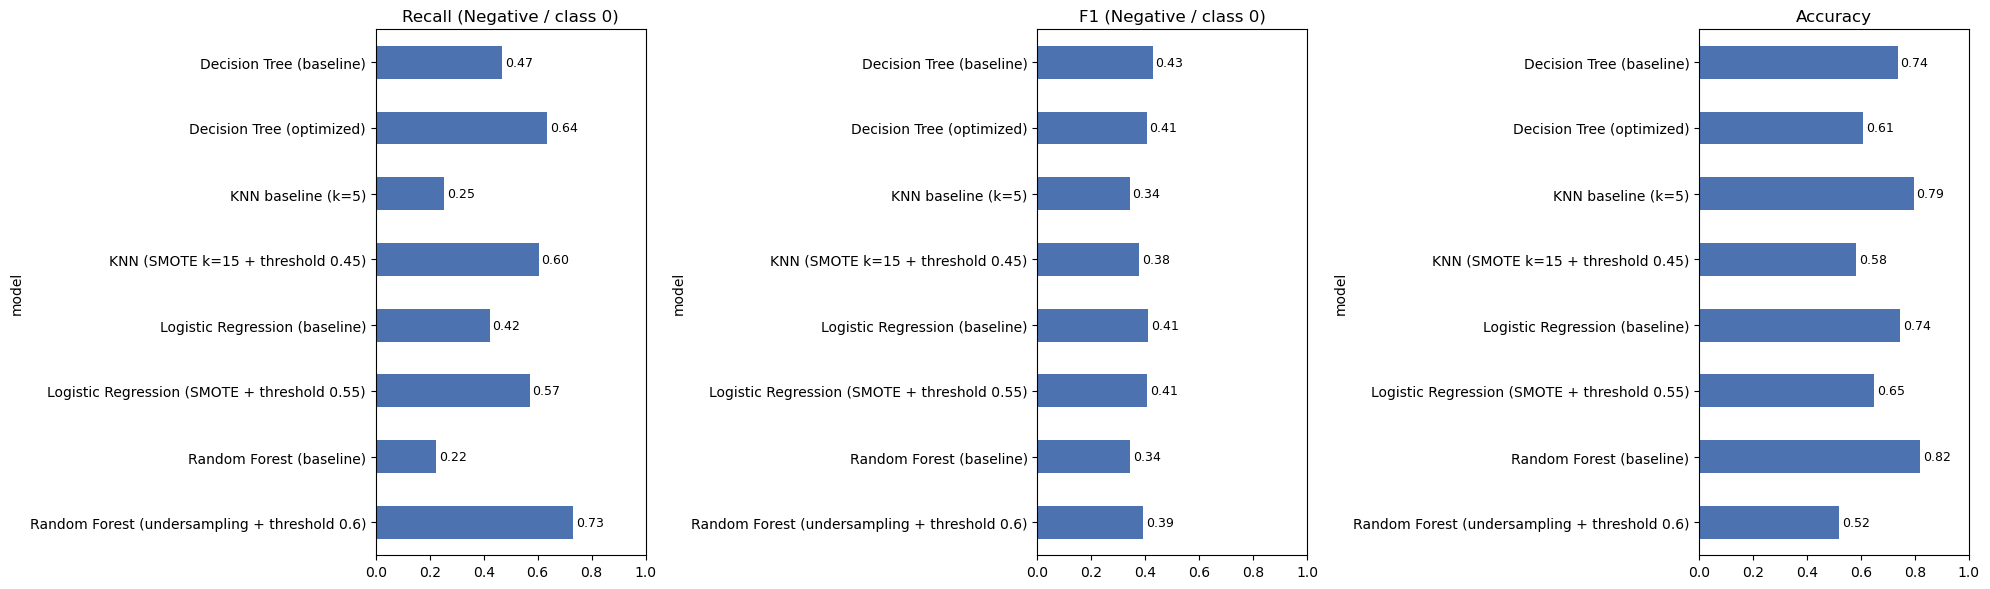

In [17]:
# Bar chart: so sanh tat ca phien ban tren Recall(0), F1(0), Accuracy
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, metric, title in zip(
        axes,
        ["recall_neg0", "f1_neg0", "accuracy"],
        ["Recall (Negative / class 0)", "F1 (Negative / class 0)", "Accuracy"]):
    results_df.plot(kind="barh", x="model", y=metric, ax=ax, legend=False, color="#4C72B0")
    ax.set_title(title); ax.set_xlim(0, 1); ax.invert_yaxis()
    for i, v in enumerate(results_df[metric]):
        ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

## 7. Kết luận (Conclusion)

Tất cả 4 mô hình dùng chung **14 features** và cùng tập train/test. Kết quả (xem bảng và biểu đồ ở mục 6) cho thấy một **đánh đổi rõ ràng giữa Accuracy/Precision và Recall của class 0** (review xấu) — đúng với bản chất bài toán cảnh báo sớm trên dữ liệu mất cân bằng.

**Theo từng mục tiêu:**

- **Accuracy / Precision cao nhất (ít báo động giả):** **Random Forest (baseline)** mạnh nhất — accuracy ≈ **0.82**, precision class 0 ≈ **0.73**. Nhưng recall class 0 chỉ ≈ **0.22**, tức **bỏ sót gần 78% review xấu**.
- **Bắt được nhiều review xấu nhất (Recall class 0):** **Random Forest (undersampling + threshold 0.60)** đạt recall ≈ **0.73**, cao nhất toàn bộ, đổi lại accuracy giảm còn ≈ **0.52**. Hai lựa chọn cân bằng hơn: **Decision Tree (optimized)** recall ≈ 0.64 (acc ≈ 0.61) và **KNN (SMOTE + threshold)** recall ≈ 0.60 (acc ≈ 0.58).
- **Cân bằng tốt nhất (F1 class 0):** các **baseline đơn giản** lại cho F1 class 0 tốt nhất — **Decision Tree baseline ≈ 0.43**, **Logistic Regression baseline ≈ 0.41**.

**Nhận xét chung:**

- Các kỹ thuật cải thiện (SMOTE, undersampling, hạ/nâng ngưỡng) **đều làm tăng mạnh Recall của class 0** nhưng **giảm Accuracy và Precision** — phù hợp khi chi phí *bỏ sót* một khách sắp đánh giá xấu (False Negative) lớn hơn chi phí *báo động nhầm* (False Positive).
- **Khuyến nghị:** nếu mục tiêu chính là **hệ thống cảnh báo sớm review xấu**, nên dùng **Random Forest + undersampling + threshold** (bắt nhiều review xấu nhất) hoặc **Decision Tree optimized / KNN+SMOTE** nếu muốn cân bằng hơn giữa recall và accuracy. Nếu cần một mô hình tổng quát chính xác cao, **Random Forest baseline** là lựa chọn tốt nhất.
- Ngưỡng quyết định và mức độ cân bằng dữ liệu nên được điều chỉnh theo **năng lực thực tế của đội chăm sóc khách hàng**.